### 1: Importación de librerías y carga del dataset

Agrega las herramientas de preprocesamiento y el modelo lineal a las librerías que ya venías utilizando.

In [12]:
# --- CELDA 1 ---
# Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Scikit-Learn y XGBoost
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Carga de datos
df = pd.read_csv('dataset_eva_final.csv')
print("Forma inicial del dataset:", df.shape)

Forma inicial del dataset: (351920, 15)


### 2: Definición de variables y limpieza de nulos

Filtramos únicamente las columnas que vamos a utilizar para evitar procesar información innecesaria.

In [13]:
# --- CELDA 2 ---
columnas_predictoras = [
    'Departamento', 'Municipio', 'Grupo_Cultivo', 'Cultivo', 
    'Anio', 'Semestre', 'Ciclo_Cultivo', 'Area_Sembrada_ha'
]
target = 'Rendimiento_t_ha'

# Nos quedamos con las variables de interés y eliminamos registros con nulos
df_model = df[columnas_predictoras + [target]].dropna()
print("Forma del dataset listo para modelar (sin nulos):", df_model.shape)

Forma del dataset listo para modelar (sin nulos): (351920, 9)


### 3: Tratamiento de Outliers (Valores Atípicos)

Aquí calculamos los cuartiles y filtramos los datos de rendimiento que se salen de la distribución normal.

Límites de rendimiento calculados: [-14.25, 27.75]
Registros antes de remover outliers: 351920
Registros después de remover outliers: 330382
Total de outliers eliminados: 21538


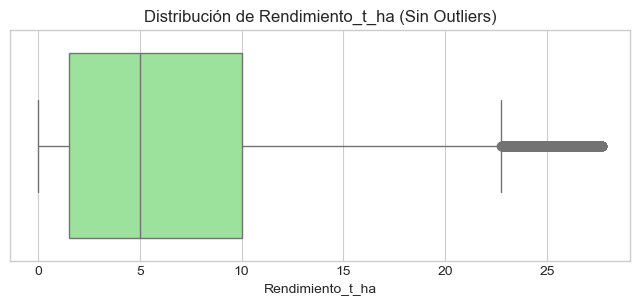

In [14]:
# --- CELDA 3 ---
# Calcular Q1, Q3 y el Rango Intercuartílico (IQR) para el target
Q1 = df_model[target].quantile(0.25)
Q3 = df_model[target].quantile(0.75)
IQR = Q3 - Q1

# Definir límites permitidos
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar el dataset para eliminar outliers
df_clean = df_model[(df_model[target] >= limite_inferior) & (df_model[target] <= limite_superior)]

print(f"Límites de rendimiento calculados: [{limite_inferior:.2f}, {limite_superior:.2f}]")
print(f"Registros antes de remover outliers: {df_model.shape[0]}")
print(f"Registros después de remover outliers: {df_clean.shape[0]}")
print(f"Total de outliers eliminados: {df_model.shape[0] - df_clean.shape[0]}")

# Visualización para comprobar la mejora
plt.figure(figsize=(8, 3))
sns.boxplot(x=df_clean[target], color='lightgreen')
plt.title('Distribución de Rendimiento_t_ha (Sin Outliers)')
plt.show()

### 4: Preprocesamiento (Encoding y Escalamiento)

Transformamos los textos a números. La Regresión Lineal es sensible a la escala de los datos numéricos, por lo que aplicaremos un StandardScaler a variables como el área sembrada y el año.

In [15]:
# --- CELDA 4 ---
df_encoded = df_clean.copy()

# 1. Label Encoding para variables categóricas
cat_cols = ['Departamento', 'Municipio', 'Grupo_Cultivo', 'Cultivo', 'Semestre', 'Ciclo_Cultivo']
label_encoders = {} # Guardamos los encoders por si necesitamos revertir o procesar nuevos datos luego

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le  

# 2. Separar variables predictoras (X) de la variable objetivo (y)
X = df_encoded[columnas_predictoras]
y = df_encoded[target]

# 3. Escalar variables continuas (Vital para la Regresión Lineal)
scaler = StandardScaler()
cols_numericas = ['Anio', 'Area_Sembrada_ha']
X[cols_numericas] = scaler.fit_transform(X[cols_numericas])

# 4. División de Entrenamiento y Prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (264305, 8)
Datos de prueba: (66077, 8)


### 5: Entrenamiento Múltiple y Comparación

Creamos un diccionario con la Regresión Lineal como nuestro baseline a superar, y los algoritmos basados en árboles como modelos avanzados.

In [16]:
# --- CELDA 5 ---
# Inicializamos los modelos a evaluar
modelos = {
    'Regresión Lineal': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

resultados = []

# Entrenar, predecir y evaluar en un solo bucle
for nombre, modelo in modelos.items():
    # Entrenamiento
    modelo.fit(X_train, y_train)
    # Predicción
    y_pred = modelo.predict(X_test)
    
    # Cálculo de métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Guardar resultados
    resultados.append({
        'Modelo': nombre,
        'RMSE': rmse,
        'MAE': mae,
        'R2 Score': r2
    })

# Formateamos como DataFrame para análisis
df_resultados = pd.DataFrame(resultados).sort_values(by='R2 Score', ascending=False)
display(df_resultados)

,Modelo,RMSE,MAE,R2 Score
1,Random Forest,2.659385,1.457067,0.823376
2,XGBoost,3.608126,2.383489,0.674876
0,Regresión Lineal,5.849371,4.623945,0.145515


### 6: Gráfico de Selección del Mejor

ModeloGraficaremos el $R^2$ (que nos dice qué porcentaje de la variabilidad del rendimiento logran explicar los datos) para tomar la decisión final con respaldo visual.

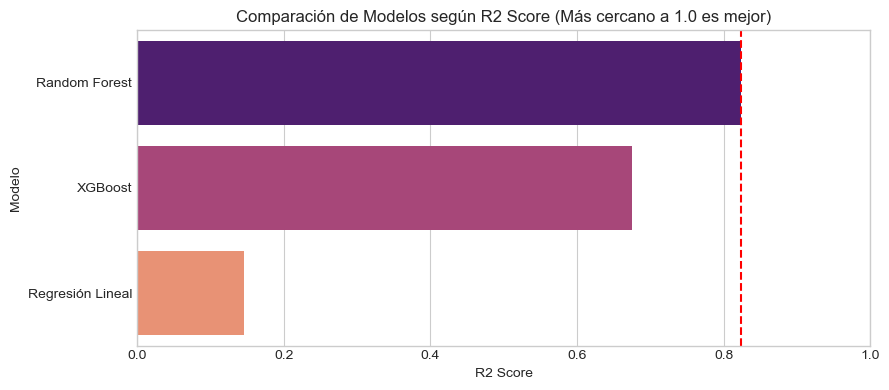

🏆 El modelo recomendado para continuar con las predicciones es: Random Forest


In [17]:
# --- CELDA 6 ---
plt.figure(figsize=(9, 4))
sns.barplot(x='R2 Score', y='Modelo', data=df_resultados, palette='magma')
plt.title('Comparación de Modelos según R2 Score (Más cercano a 1.0 es mejor)')
plt.xlim(0, 1)
plt.axvline(x=df_resultados['R2 Score'].max(), color='red', linestyle='--')
plt.tight_layout()
plt.show()

# Imprimir conclusión automatizada
mejor_modelo_nombre = df_resultados.iloc[0]['Modelo']
print(f"🏆 El modelo recomendado para continuar con las predicciones es: {mejor_modelo_nombre}")

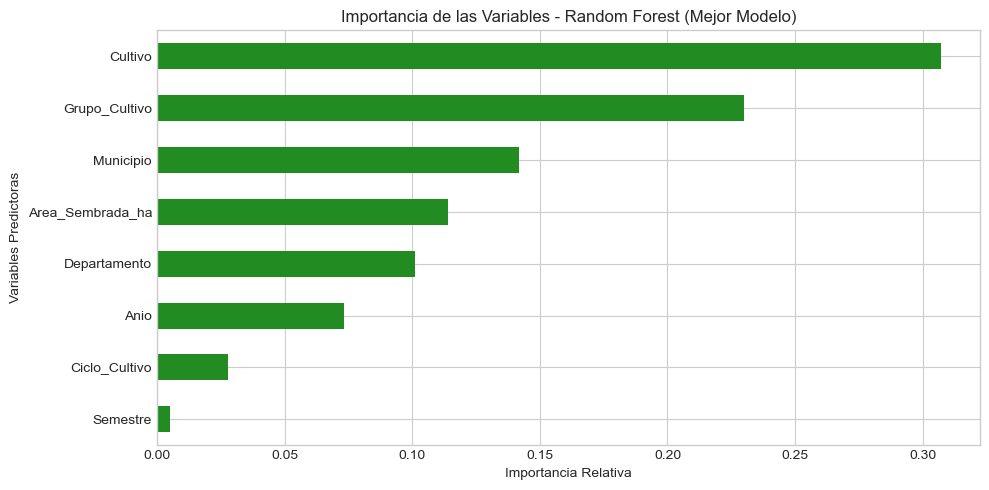

In [18]:
# --- CELDA 7: Importancia de Variables (Mejor Modelo) ---

# Extraemos el modelo Random Forest ya entrenado de nuestro diccionario 'modelos'
rf_model = modelos['Random Forest']

# Obtenemos la importancia de cada variable predictora
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Ordenamos y graficamos las 8 variables con mayor impacto
plt.figure(figsize=(10,5))
feat_importances.nlargest(8).sort_values().plot(kind='barh', color='forestgreen')
plt.title('Importancia de las Variables - Random Forest (Mejor Modelo)')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variables Predictoras')
plt.tight_layout()
plt.show()

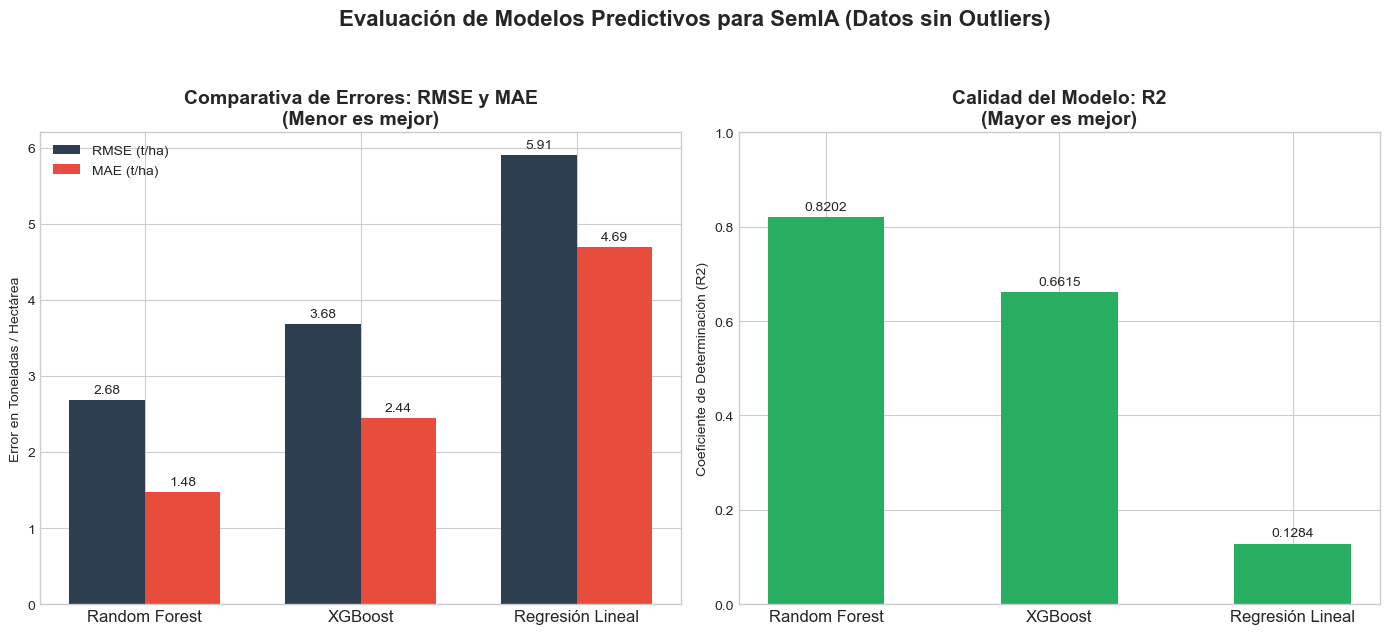

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# --- CELDA 8: Gráfica comparativa final de los 3 modelos ---

# Nuevos datos de evaluación tras la limpieza de outliers
modelos = ['Random Forest', 'XGBoost', 'Regresión Lineal']
# Valores obtenidos en la evaluación anterior
rmse = [2.6828, 3.6812, 5.9074]
mae = [1.4767, 2.4436, 4.6943]
r2 = [0.8202, 0.6615, 0.1284]

# Configuración de estilo visual
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Subgráfico 1: Comparación de Errores (Menor es mejor) ---
x = np.arange(len(modelos))
width = 0.35

rects1 = ax1.bar(x - width/2, rmse, width, label='RMSE (t/ha)', color='#2c3e50')
rects2 = ax1.bar(x + width/2, mae, width, label='MAE (t/ha)', color='#e74c3c')

ax1.set_ylabel('Error en Toneladas / Hectárea')
ax1.set_title('Comparativa de Errores: RMSE y MAE\n(Menor es mejor)', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(modelos, fontsize=12)
ax1.legend()

# Añadir etiquetas de datos
ax1.bar_label(rects1, padding=3, fmt='%.2f')
ax1.bar_label(rects2, padding=3, fmt='%.2f')

# --- Subgráfico 2: Comparación de R2 (Mayor es mejor) ---
rects3 = ax2.bar(modelos, r2, width=0.5, color='#27ae60')

ax2.set_ylabel('Coeficiente de Determinación (R2)')
ax2.set_title('Calidad del Modelo: R2\n(Mayor es mejor)', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1) # El R2 va de 0 a 1
ax2.tick_params(axis='x', labelsize=12)

# Añadir etiquetas de datos
ax2.bar_label(rects3, padding=3, fmt='%.4f')

# Ajuste de layout y renderizado
plt.suptitle('Evaluación de Modelos Predictivos para SemIA (Datos sin Outliers)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 7: Empaquetamiento de Componentes (Exportación MLOps)

Utilizaremos joblib para agrupar el modelo entrenado y los transformadores matemáticos en un único archivo serializado comprimido.

In [20]:
import joblib

# Creamos un diccionario unificado con todos los artefactos requeridos para producción
artefactos_semia = {
    'modelo': rf_model, # <--- ¡Aquí está el cambio clave! Usamos la variable directa
    'encoders': label_encoders,
    'scaler': scaler,
    'columnas_predictoras': columnas_predictoras
}

# Guardamos los artefactos en un archivo binario comprimido
joblib.dump(artefactos_semia, 'componentes_semia_rf.pkl', compress=3)

print("📦 ¡Éxito de exportación!")
print("El modelo Random Forest y sus componentes de preprocesamiento fueron empaquetados en 'componentes_semia_rf.pkl'.")
print("Este archivo es el que subiremos al Bucket de Google Cloud Storage para que FastAPI lo consuma.")

📦 ¡Éxito de exportación!
El modelo Random Forest y sus componentes de preprocesamiento fueron empaquetados en 'componentes_semia_rf.pkl'.
Este archivo es el que subiremos al Bucket de Google Cloud Storage para que FastAPI lo consuma.


 ### 8: Construcción del Motor de Recomendación SemIA
 
 Esta función replica de manera exacta la ingeniería de características inversa. Lee las combinaciones de cultivos históricas aptas para el municipio consultado, construye la matriz sintética para el año y área deseados, ejecuta la inferencia y calcula la producción total estimada ($\text{Rendimiento} \times \text{Área}$).

In [21]:
def motor_recomendacion_semia(municipio_input, anio_input, semestre_input, area_input, path_artefactos='componentes_semia_rf.pkl'):
    """
    Motor de Inferencia de SemIA: 
    Carga los componentes guardados, filtra los cultivos aptos de la región 
    y genera el Top 5 basado en proyecciones matemáticas del Random Forest.
    """
    # 1. Cargar los artefactos serializados
    artefactos = joblib.load(path_artefactos)
    modelo_rf = artefactos['modelo']
    encoders = artefactos['encoders']
    scaler_rf = artefactos['scaler']
    cols_predictoras = artefactos['columnas_predictoras']
    
    # 2. Extraer las combinaciones biológicamente viables para ese municipio (evita recomendar cultivos imposibles)
    opciones_regionales = df_clean[df_clean['Municipio'] == municipio_input][
        ['Departamento', 'Municipio', 'Grupo_Cultivo', 'Cultivo', 'Ciclo_Cultivo']
    ].drop_duplicates()
    
    if opciones_regionales.empty:
        return f"❌ El municipio '{municipio_input}' no se encuentra en el registro histórico de las EVA."
    
    # 3. Construir la matriz de características sintética para pasar al modelo
    df_inferencia = opciones_regionales.copy()
    df_inferencia['Anio'] = anio_input
    df_inferencia['Semestre'] = semestre_input
    df_inferencia['Area_Sembrada_ha'] = area_input
    
    # Asegurar el orden exacto de las columnas predictoras exigido por sklearn
    df_inferencia = df_inferencia[cols_predictoras]
    
    # 4. Transformación de datos en tiempo de ejecución (Inferencia Pipeline)
    cat_cols = ['Departamento', 'Municipio', 'Grupo_Cultivo', 'Cultivo', 'Semestre', 'Ciclo_Cultivo']
    for col in cat_cols:
        le = encoders[col]
        # Validar categorías no vistas por seguridad en producción
        df_inferencia[col] = df_inferencia[col].map(lambda s: s if s in le.classes_ else le.classes_[0])
        df_inferencia[col] = le.transform(df_inferencia[col].astype(str))
    
    # Escalar variables continuas numéricas
    cols_numericas = ['Anio', 'Area_Sembrada_ha']
    df_inferencia[cols_numericas] = scaler_rf.transform(df_inferencia[cols_numericas])
    
    # 5. Ejecución de la Predicción
    rendimientos_predichos = modelo_rf.predict(df_inferencia)
    
    # 6. Estructurar y formatear la respuesta del recomendador
    resultados = opciones_regionales.copy()
    resultados['Rendimiento_Proyectado_t_ha'] = rendimientos_predichos
    resultados['Produccion_Total_Estimada_t'] = rendimientos_predichos * area_input
    
    # Filtrar, ordenar descendentemente por rendimiento y extraer el Top 5
    top5_recomendaciones = resultados.sort_values(by='Rendimiento_Proyectado_t_ha', ascending=False).head(5)
    
    return top5_recomendaciones.reset_index(drop=True)

### 9: Prueba de Inferencia Real del Sistema (Ejemplo de Consulta)

Ejecutamos un caso de uso idéntico al comportamiento esperado por la interfaz conversacional de SemIA. Simularemos una consulta para el municipio de Cumaribo en el año 2026 sobre un terreno de 10 hectáreas.

In [22]:
# Definición de parámetros para la simulación de consulta del usuario
municipio_test = 'CUMARIBO'
anio_test = 2026
semestre_test = 'A'
area_test = 10.0

print(f"🧠 Consultando el Motor Predictivo de SemIA para:")
print(f"📍 Municipio: {municipio_test} | 📅 Año: {anio_test} | 🌤️ Semestre: {semestre_test} | 📐 Área: {area_test} ha\n")

# Invocación del motor de inferencia
tabla_resultados = motor_recomendacion_semia(
    municipio_input=municipio_test,
    anio_input=anio_test,
    semestre_input=semestre_test,
    area_input=area_test
)

# Renderizado elegante de los resultados en el notebook
if isinstance(tabla_resultados, pd.DataFrame):
    print("=========================================================================")
    print("🏆   SEMIA: TOP 5 CULTIVOS RECOMENDADOS SEGÚN RENDIMIENTO PROYECTADO   🏆")
    print("=========================================================================")
    display(tabla_resultados[['Grupo_Cultivo', 'Cultivo', 'Ciclo_Cultivo', 'Rendimiento_Proyectado_t_ha', 'Produccion_Total_Estimada_t']])
else:
    print(tabla_resultados)

🧠 Consultando el Motor Predictivo de SemIA para:
📍 Municipio: CUMARIBO | 📅 Año: 2026 | 🌤️ Semestre: A | 📐 Área: 10.0 ha

🏆   SEMIA: TOP 5 CULTIVOS RECOMENDADOS SEGÚN RENDIMIENTO PROYECTADO   🏆


,Grupo_Cultivo,Cultivo,Ciclo_Cultivo,Rendimiento_Proyectado_t_ha,Produccion_Total_Estimada_t
0,FRUTALES,MARACUYA,PERMANENTE,15.657200,156.572000
1,FRUTALES,PATILLA,TRANSITORIO,13.856750,138.567500
2,FRUTALES,NARANJA,PERMANENTE,12.112100,121.121000
3,TUBERCULOS Y PLATANOS,YUCA,PERMANENTE,11.609347,116.093473
4,FRUTALES,MANDARINA,PERMANENTE,11.593531,115.935315
